# 🔆 Stage 3 · Improving

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DreamEmulator/rtu-computer-vision/blob/main/02_image-preprocessing/improving.ipynb)

**Topic of the week:** Image Preprocessing Methods · **Lecture:** Thu 24.09 · **Startup question:** *Night shift on the ward: will we still see anything in dim light?*

Nearly half of our frames are taken in a dim ward: all brightness values squeezed into a narrow band. Contrast enhancement spreads that band out again. Edges, the places where brightness changes fast, are where shapes begin.

| In the CI-pipeline | |
|---|---|
| Why? | [`README.md`](README.md) |
| How? — the 🎛️ tinker zone | [`improving_enhance/action.yaml`](improving_enhance/action.yaml) |
| What? — Step 0 to 3 | [`Todo_Improving.md`](Todo_Improving.md) |
| Code | `stages/s3_improving.py` |

This notebook imports the **same functions** CI runs, with the values from your tinker zone. Explore here, then commit your choice to the tinker zone on a branch and let CI prove it.

In [1]:
# ⚙️ Setup — works locally, in Codespaces and in Colab (Colab already has every library we need)
import os, subprocess, sys
REPO = "DreamEmulator/rtu-computer-vision"  # filled in automatically in your own copy of the template
here = os.getcwd()
while not os.path.exists("run_pipeline.py") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                      # notebooks live in the topic folders; the pipeline root is up
if not os.path.exists("run_pipeline.py"):   # Colab: fetch the repository first
    os.chdir(here)
    if not os.path.exists("repo"):
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", "repo"], check=True)
    os.chdir("repo")
sys.path.insert(0, os.getcwd())

import cv2, json, numpy as np, matplotlib.pyplot as plt
from stages.common import load_images, to_luma
from stages.nb import prepare, run_stage, show
%matplotlib inline

In [2]:
cfg = prepare("cleaning")
from stages.s3_improving import enhance, edges, contrast
s2 = load_images("cleaning"); sp = s2.color_space
stds = np.array([contrast(im, sp) for im in s2.images])
img = s2.images[int(stds.argmin())]
print(f"Dimmest frame has brightness σ = {stds.min():.1f}; the brightest-contrast frame has {stds.max():.1f}")

✔ Stages up to 'cleaning' ran with your tinker-zone values
Dimmest frame has brightness σ = 6.7; the brightest-contrast frame has 40.9


## Four ways to stretch a histogram

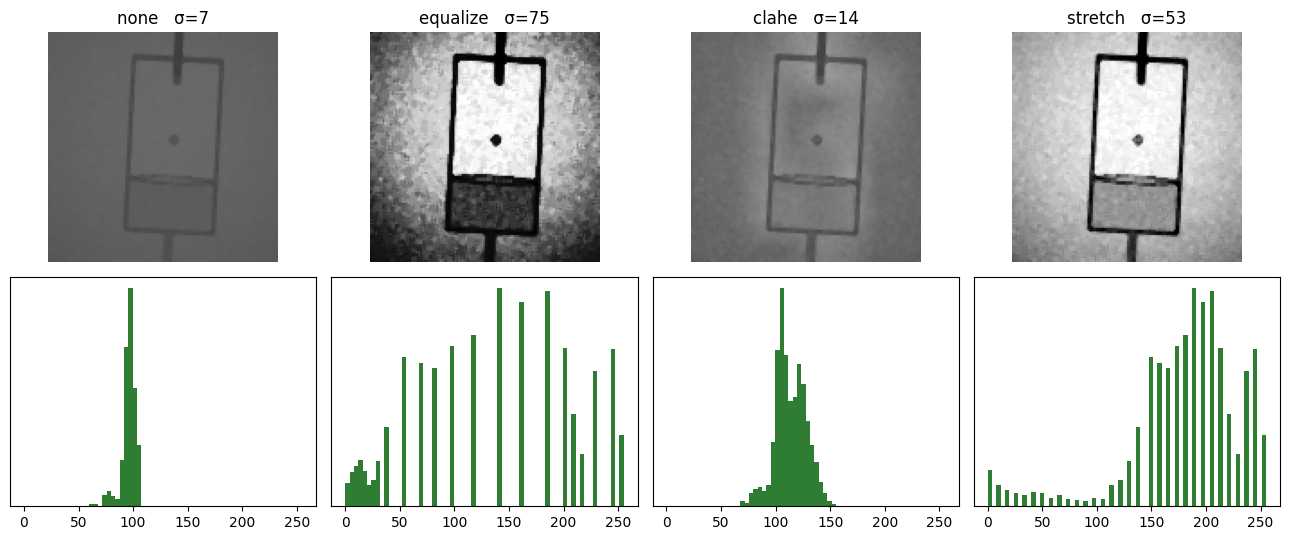

In [3]:
methods = ["none", "equalize", "clahe", "stretch"]
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for k, m in enumerate(methods):
    g = to_luma(enhance(img, {**cfg["improving"], "method": m}, sp), sp)
    axes[0, k].imshow(g, cmap="gray", vmin=0, vmax=255); axes[0, k].set_title(f"{m}   σ={g.std():.0f}"); axes[0, k].axis("off")
    axes[1, k].hist(g.ravel(), bins=64, range=(0, 255), color="#2e7d32"); axes[1, k].set_yticks([])
plt.tight_layout(); plt.show()

## CLAHE's clip limit
CLAHE equalizes every tile separately, but clips each tile's histogram first so it doesn't blow up noise. The gate looks at the **dimmest 5%** of frames.

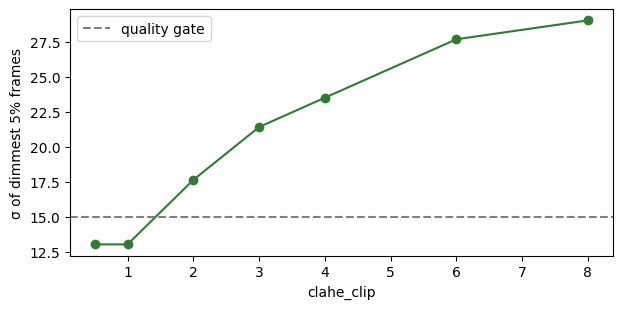

In [4]:
clips = [0.5, 1, 2, 3, 4, 6, 8]
sample = s2.images[::3]
p5 = [np.percentile([contrast(enhance(im, {**cfg["improving"], "method": "clahe", "clahe_clip": c}, sp), sp)
                     for im in sample], 5) for c in clips]
plt.figure(figsize=(7, 3.2)); plt.plot(clips, p5, "o-", c="#2e7d32")
gate = cfg["improving"].get("gate_min_dim_contrast")
if gate is not None: plt.axhline(gate, ls="--", c="gray", label="quality gate"); plt.legend()
plt.xlabel("clahe_clip"); plt.ylabel("σ of dimmest 5% frames"); plt.show()

## Gradients and Canny
Sobel filters measure how fast brightness changes in x and y. Canny thins those gradients to one-pixel edges and keeps weak edges only when they touch strong ones (hysteresis).

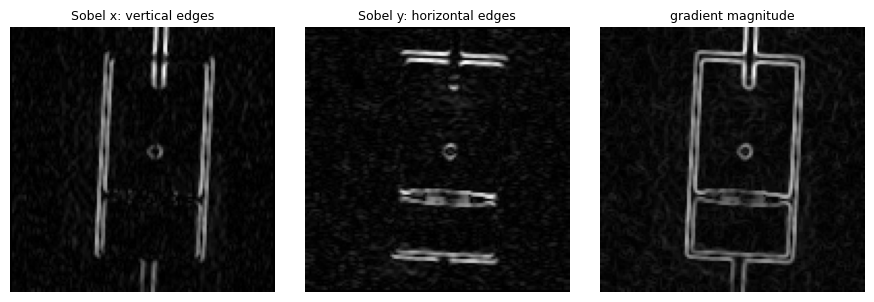

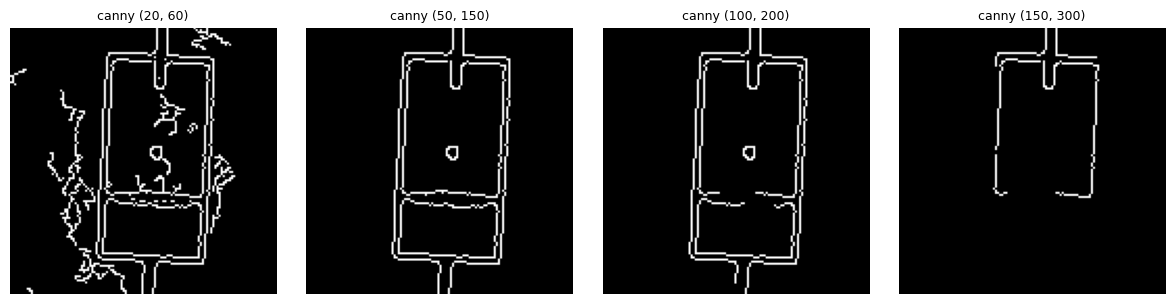

In [5]:
enh = enhance(img, cfg["improving"], sp)
g = to_luma(enh, sp).astype(np.float32)
gx, gy = cv2.Sobel(g, cv2.CV_32F, 1, 0), cv2.Sobel(g, cv2.CV_32F, 0, 1)
norm = lambda a: cv2.normalize(np.abs(a), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
show([norm(gx), norm(gy), norm(np.hypot(gx, gy))], ["Sobel x: vertical edges", "Sobel y: horizontal edges", "gradient magnitude"], size=3)
pairs = [(20, 60), (50, 150), (100, 200), (150, 300)]
show([edges(enh, {"canny_low": p[0], "canny_high": p[1]}, sp) for p in pairs], [f"canny {p}" for p in pairs], size=3)

## 🧪 Your turn — a real startup argument
Set `improving.method: none` and push. On our data the **test accuracy may go up while the contrast gate fails.**

* Stage 5's HOG normalises contrast inside every block, so the classifier barely needs this stage. Does that make the gate wrong?
* Or does the gate protect against something the test set doesn't show (a darker ward, a new camera)?

Decide as a team: change the gate, or keep the stage. Write the argument in your PR. Gates are decisions, not laws of nature.

## 🚀 Ship your choice

1. Create a branch: `experiment/<what-you-change>`
2. Change **one** value in the 🎛️ TINKER ZONE of this topic's `action.yaml`
3. Push and open a pull request. The PR template asks for your hypothesis and result.
4. Compare the 🎤 Demo Day table of your PR with the one on `main`. Better? Merge. Not better? Close it and write down why — that's R&D too.